In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
%pip install -q dagshub mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 549.5 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 949.9 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 2.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 36.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 55.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.2 MB/s eta 0:

In [3]:
import dagshub
dagshub.init(repo_owner='mesata', repo_name='IEE-CIS-Fraud-Detection', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=0a57b483-cc81-4bcf-9b4f-c3df2b6ec095&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=7a438b03e6ea7387620ad1c72938eecda36523ac5aa8167c167a6c74d5abb7c1




Output()

Accessing as mesata

Initialized MLflow to track repo "mesata/IEE-CIS-Fraud-Detection"

Repository mesata/IEE-CIS-Fraud-Detection initialized!

🏃 View run ambitious-auk-962 at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/424194786f7c435e80f346c12daa5e3a
🧪 View experiment at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0


# CLEANING


In [4]:
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

In [5]:
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
del train_transaction, train_identity

In [6]:
nan_stats = train.isnull().mean()
cols_to_drop = nan_stats[nan_stats > 0.8].index
train = train.drop(columns=cols_to_drop) 
num_cols = train.select_dtypes(include=[np.number]).columns
train[num_cols] = train[num_cols].fillna(train[num_cols].median())
print(f"წაიშალა {len(cols_to_drop)} სვეტი. დარჩა {train.shape[1]} სვეტი.")

წაიშალა 74 სვეტი. დარჩა 360 სვეტი.


# FEATURE ENGINEERING

In [7]:
train['TransactionHour'] = (train['TransactionDT'] // 3600) % 24
from sklearn.preprocessing import LabelEncoder
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))

print(f"Encrypted {len(cat_cols)} categorical columns.")

/tmp/ipykernel_56/2022649153.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionHour'] = (train['TransactionDT'] // 3600) % 24


Encrypted 26 categorical columns.


# FEATURE SELECTION

In [8]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01) 
train_selected = train.copy()
num_features = train.select_dtypes(include=[np.number]).columns
selector.fit(train[num_features])
features_to_keep = num_features[selector.get_support()]
all_features = list(features_to_keep) + list(train.select_dtypes(include=['object']).columns)
train = train[all_features]
print(f"Variance Threshold-ის შემდეგ დარჩა {train.shape[1]} სვეტი.")
corr_matrix = train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
train = train.drop(columns=to_drop)
print(f"მაღალი კორელაციის გამო წაიშალა {len(to_drop)} სვეტი.")
print(f"საბოლოო ჯამში დაგვრჩა {train.shape[1]} ყველაზე ინფორმატიული სვეტი.")

Variance Threshold-ის შემდეგ დარჩა 337 სვეტი.
მაღალი კორელაციის გამო წაიშალა 90 სვეტი.
საბოლოო ჯამში დაგვრჩა 247 ყველაზე ინფორმატიული სვეტი.


# TRAINING

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
X = train.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1, errors='ignore')
y = train['isFraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

with mlflow.start_run(run_name="DecisionTree_Filtered_Data"):
    dt_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42)
    dt_model.fit(X_train, y_train)
    y_pred = dt_model.predict_proba(X_val)[:, 1]
    auc_score = roc_auc_score(y_val, y_pred)
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("auc", auc_score)
    print(f"Decision Tree AUC: {auc_score:.4f}")

Decision Tree AUC: 0.8337
🏃 View run DecisionTree_Filtered_Data at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/6e7bdccfb1774120a08eaf727313085f
🧪 View experiment at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0


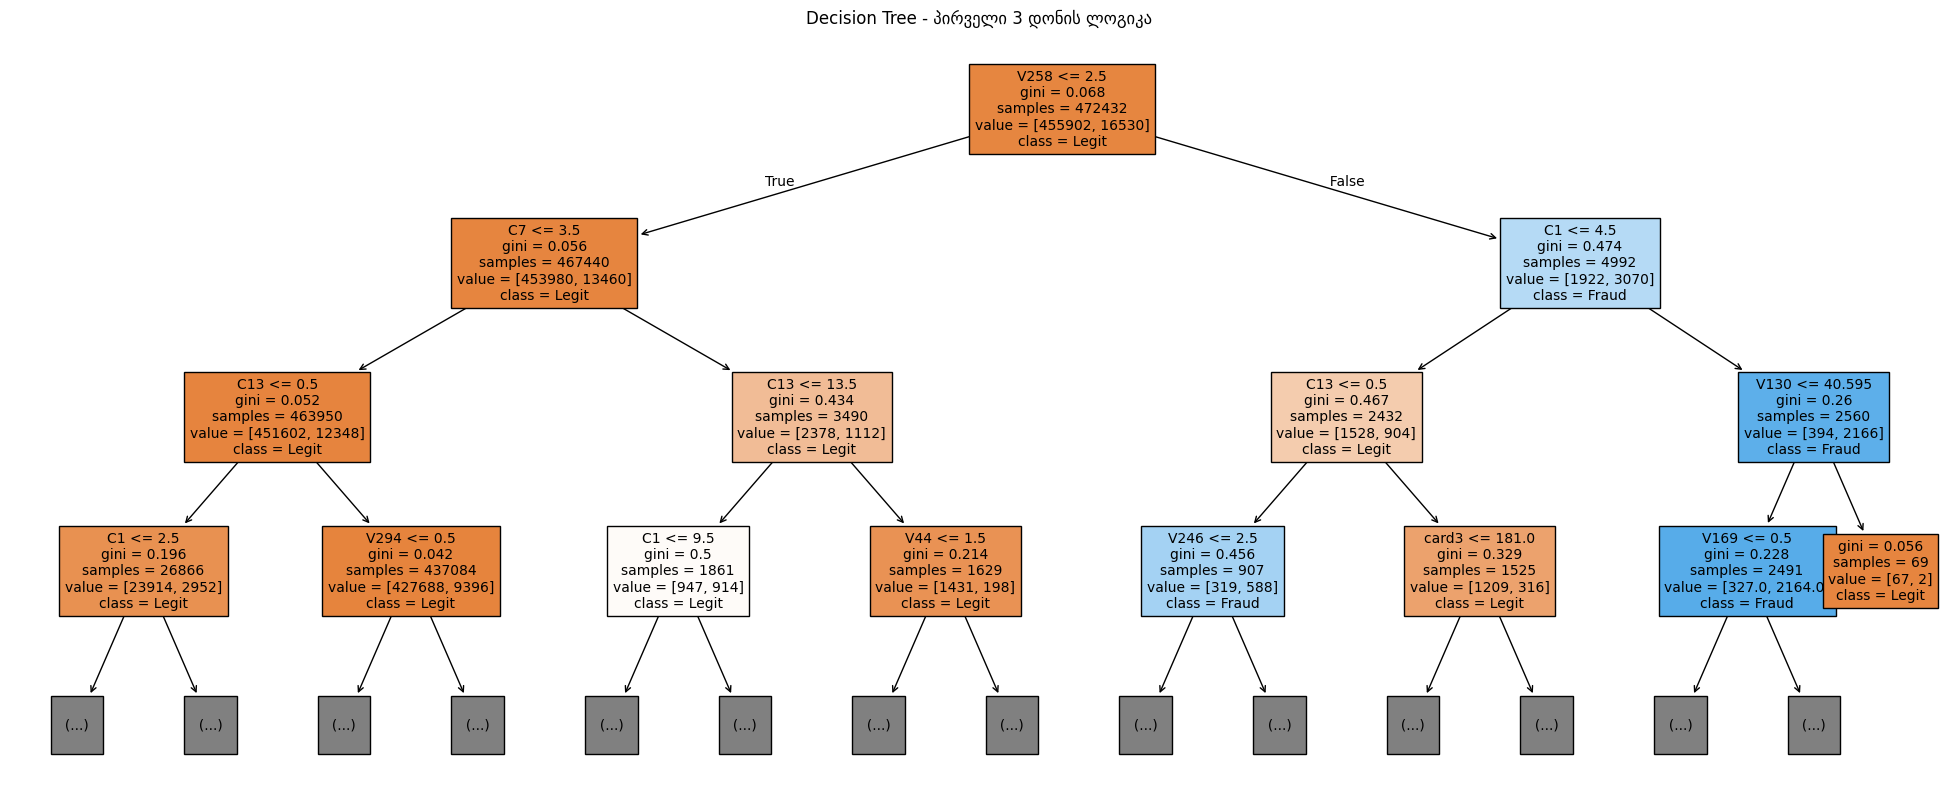

In [10]:
plt.figure(figsize=(25,10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['Legit', 'Fraud'], 
          filled=True, 
          max_depth=3, 
          fontsize=10)
plt.title("Decision Tree - პირველი 3 დონის ლოგიკა")
plt.show()

/tmp/ipykernel_56/670876535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=dt_imp, palette="magma")


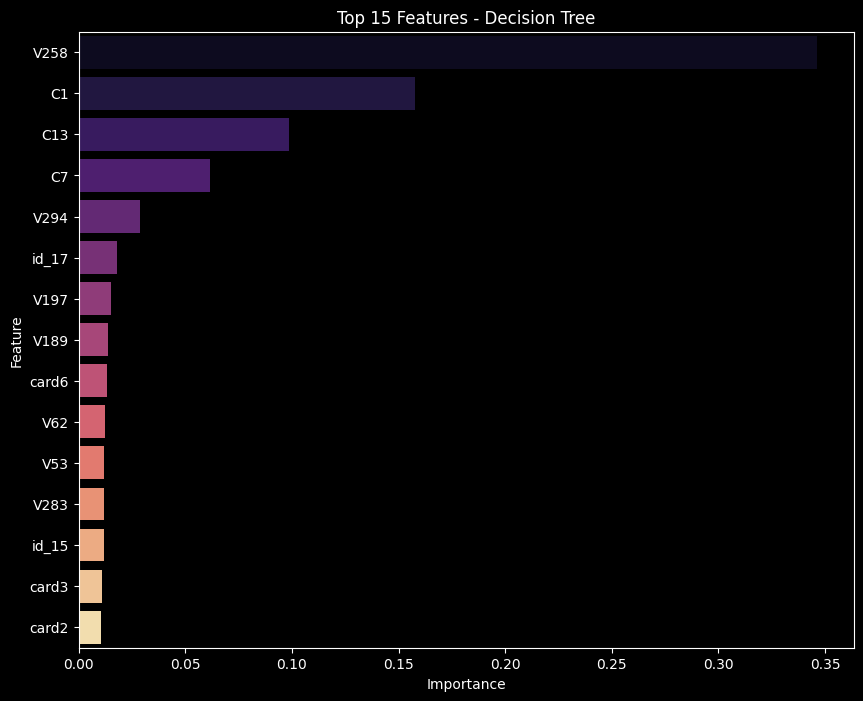

In [15]:
dt_imp = pd.DataFrame({'Feature': X.columns, 'Importance': dt_model.feature_importances_})
dt_imp = dt_imp.sort_values(by='Importance', ascending=False).head(15)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=dt_imp, palette="magma")
plt.title("Top 15 Features - Decision Tree")
plt.show()